In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [5]:
data = pd.read_csv('heart222.csv')

In [6]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
 data_dup = data.duplicated().any()

In [8]:
data_dup

np.True_

In [9]:
data = data.drop_duplicates()

In [10]:
data_dup = data.duplicated().any()

In [11]:
data_dup

np.False_

In [12]:
cate_val = []
cont_val = []
for column in data.columns:
  if data[column].nunique() <= 10:
    cate_val.append(column)
  else:
    cont_val.append(column)

In [13]:
cate_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [14]:
cont_val

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [15]:
cate_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [16]:
data['cp'].unique()

array([0, 1, 2, 3])

In [17]:
cate_val.remove('sex')
cate_val.remove('target')
data = pd.get_dummies(data, columns = cate_val, drop_first = True)

In [18]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [19]:
 from sklearn.preprocessing import StandardScaler

In [20]:
st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])

In [21]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [22]:
X = data.drop('target', axis=1)

In [23]:
y = data['target']

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_test

,age,sex,trestbps,chol,thalach,oldpeak,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
245,-1.153610,1,-0.091401,-0.532247,1.680713,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
349,0.839089,0,-0.091401,0.319348,-2.299069,0.135360,False,True,False,False,...,False,True,False,True,False,False,False,False,False,True
135,0.396267,0,2.189843,-0.416120,-0.156110,1.515232,False,False,False,True,...,True,True,False,False,True,False,False,True,False,False
389,0.949794,1,0.764066,-0.261285,0.018826,1.084022,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
66,-0.157260,1,-0.091401,-0.958045,0.106294,0.135360,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,1.724733,1,1.391408,-0.029032,-0.287311,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
123,1.171205,0,0.478910,3.299932,0.324963,-0.209608,False,True,False,True,...,False,False,True,True,False,False,False,False,True,False
739,-0.267966,1,-0.205463,0.164513,0.499898,-0.899544,False,False,False,False,...,True,False,True,True,False,False,False,False,False,True
274,1.281911,1,1.619532,-0.358057,-0.505981,1.084022,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [27]:
X_train

,age,sex,trestbps,chol,thalach,oldpeak,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
163,-0.710788,1,-0.433587,0.532247,0.718568,-0.468334,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
291,0.396267,1,-0.205463,0.241930,-0.855851,1.687716,False,False,False,False,...,True,True,False,False,True,False,False,False,False,True
280,-1.042904,0,-0.091401,-0.241930,1.112172,-0.382092,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
85,-1.153610,1,-0.661712,-0.512893,0.893503,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
239,0.839089,0,1.049221,-0.048386,0.193761,0.307844,False,False,False,False,...,True,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,1.392616,1,-0.661712,-0.183867,-3.436149,-0.037124,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
77,0.949794,1,0.478910,-1.151589,-0.243577,2.550136,False,False,False,False,...,True,False,True,False,True,False,False,False,False,True
125,0.617678,0,1.049221,-0.125804,0.937237,-0.123366,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
522,1.392616,0,1.163283,0.590310,0.980971,-0.899544,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False


In [28]:
y_test

245    1
349    0
135    0
389    1
66     1
      ..
402    1
123    1
739    0
274    1
256    1
Name: target, Length: 61, dtype: int64

In [29]:
y_train

163    0
291    0
280    1
85     1
239    0
      ..
267    0
77     0
125    1
522    1
119    1
Name: target, Length: 241, dtype: int64

In [30]:
def calculate_metrics(true_positive, false_positive, false_negative, true_negative):
    # Precision
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0

    # Recall (Sensitivity)
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

    # Specificity
    specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0

    # F1 Score
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # False Positive Rate
    false_positive_rate = false_positive / (false_positive + true_negative) if (false_positive + true_negative) > 0 else 0

    # False Negative Rate
    false_negative_rate = false_negative / (false_negative + true_positive) if (false_negative + true_positive) > 0 else 0

    return precision, recall, specificity, f1_score, false_positive_rate, false_negative_rate



In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
log = LogisticRegression(max_iter=5000)
log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [33]:
y_pred1 = log.predict(X_test)


In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy = accuracy_score(y_test, y_pred1)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred1).ravel()
# Calculate metrics
precision, recall, specificity, f1_score, false_positive_rate, false_negative_rate = calculate_metrics(tp, fp, fn, tn)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1_score)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)



Accuracy: 0.7868852459016393
Precision: 0.75
Recall: 0.8275862068965517
Specificity: 0.75
F1 Score: 0.7868852459016394
False Positive Rate: 0.25
False Negative Rate: 0.1724137931034483


In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred1)
auc = roc_auc_score(y_test, y_pred1)

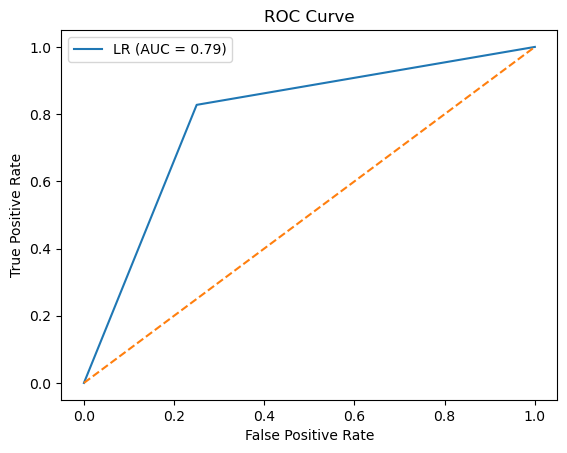

In [37]:
plt.figure()
plt.plot(fpr, tpr, label="LR (AUC = %0.2f)" % auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [38]:
from sklearn import svm

In [39]:
svm = svm.SVC()

In [40]:
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
y_pred2 = svm.predict(X_test)

In [42]:
accuracy=accuracy_score(y_test, y_pred2)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred2).ravel()
# Calculate metrics
precision, recall, specificity, f1_score, false_positive_rate, false_negative_rate = calculate_metrics(tp, fp, fn, tn)
print("Accuracy:", accuracy)


print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1_score)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

Accuracy: 0.8032786885245902
Precision: 0.7575757575757576
Recall: 0.8620689655172413
Specificity: 0.75
F1 Score: 0.8064516129032258
False Positive Rate: 0.25
False Negative Rate: 0.13793103448275862


In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred2)
auc = roc_auc_score(y_test, y_pred2)

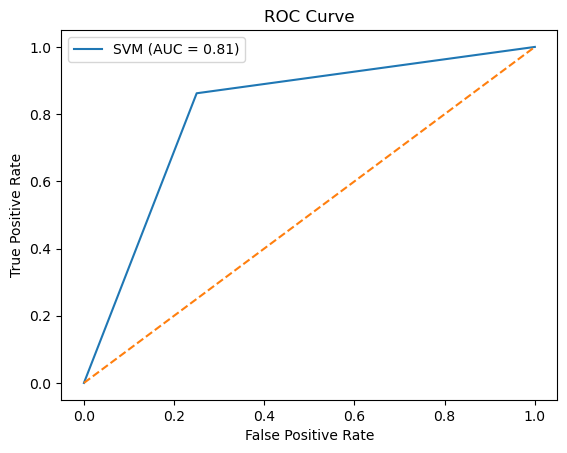

In [44]:
plt.figure()
plt.plot(fpr, tpr, label="SVM (AUC = %0.2f)" % auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
data = pd.read_csv('heart222.csv')

In [46]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [47]:
data = data.drop_duplicates()

In [48]:
data.shape

(302, 14)

In [49]:
X = data.drop('target',axis=1)
y = data['target']

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf = RandomForestClassifier()

In [53]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred3 = rf.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score

In [56]:
accuracy_score(y_test,y_pred3)

0.8360655737704918

In [57]:
accuracy=accuracy_score(y_test, y_pred3)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred3).ravel()
# Calculate metrics
precision, recall, specificity, f1_score, false_positive_rate, false_negative_rate = calculate_metrics(tp, fp, fn, tn)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1_score)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

Accuracy: 0.8360655737704918
Precision: 0.7878787878787878
Recall: 0.896551724137931
Specificity: 0.78125
F1 Score: 0.8387096774193549
False Positive Rate: 0.21875
False Negative Rate: 0.10344827586206896


In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred3)
auc = roc_auc_score(y_test, y_pred3)

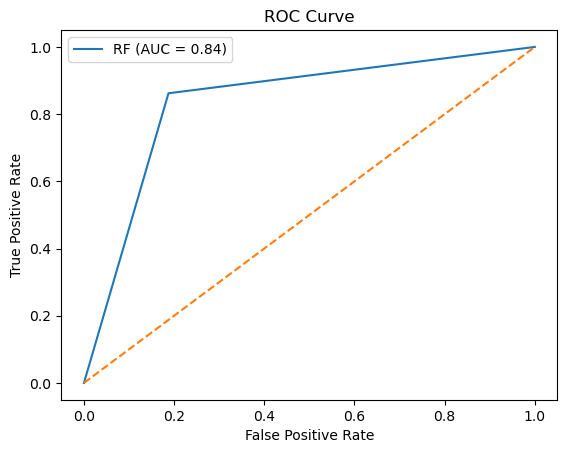

In [715]:
plt.figure()
plt.plot(fpr, tpr, label="RF (AUC = %0.2f)" % auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [716]:
final_data = pd.DataFrame({'Models': ['LR','SVM','RF'],
                           'ACC':[accuracy_score(y_test,y_pred1),
                                 accuracy_score(y_test,y_pred2),
                                 accuracy_score(y_test,y_pred3)]})

In [717]:
final_data

,Models,ACC
0,LR,0.786885
1,SVM,0.803279
2,RF,0.836066


In [718]:
import seaborn as sns

<Axes: ylabel='ACC'>

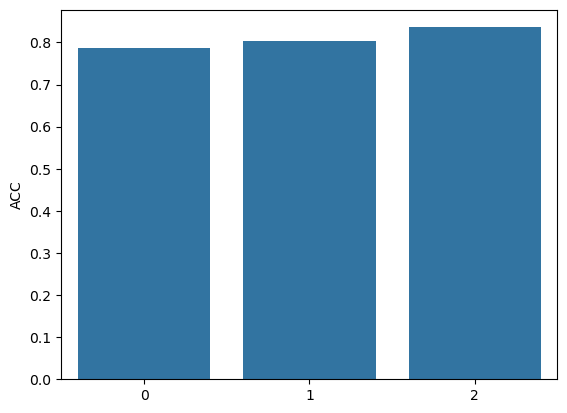

In [719]:
sns.barplot(final_data['ACC'])

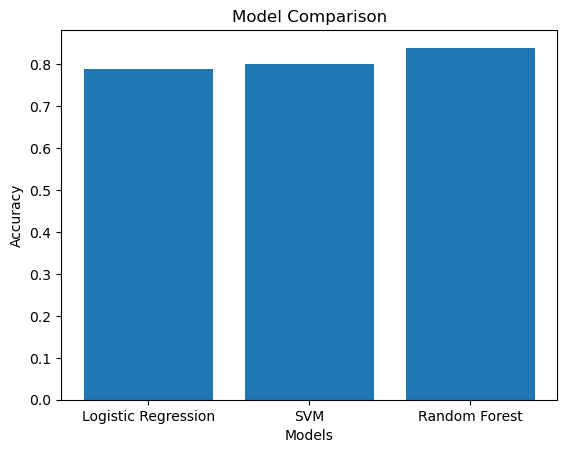

In [59]:
models = ["Logistic Regression", "SVM", "Random Forest"]
accuracies = [0.79, 0.80, 0.84]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Comparison")
plt.show()

In [802]:
Xn = data.drop('target', axis=1)

In [803]:
yn = data['target']

In [804]:
from sklearn.model_selection import train_test_split

In [805]:
Xn_train, Xn_test, yn_train, yn_test = train_test_split(Xn, yn, train_size=0.9, random_state=42)

In [806]:
from sklearn.linear_model import LogisticRegression

In [807]:
logn1 = LogisticRegression(max_iter=10000)
logn1.fit(Xn_train, yn_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [808]:
y_pred222 = logn1.predict(Xn_test)

In [809]:
from sklearn.metrics import accuracy_score

In [810]:
accuracy2 = accuracy_score(yn_test, y_pred222)
tn1, fp1, fn1, tp1 = confusion_matrix(yn_test, y_pred222).ravel()
# Calculate metrics
precision, recall, specificity, f1_score, false_positive_rate, false_negative_rate = calculate_metrics(tp1, fp1, fn1, tn1)
print("Accuracy:", accuracy2)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1_score)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)


Accuracy: 0.7741935483870968
Precision: 0.7222222222222222
Recall: 0.8666666666666667
Specificity: 0.6875
F1 Score: 0.7878787878787877
False Positive Rate: 0.3125
False Negative Rate: 0.13333333333333333


In [729]:
from sklearn.metrics import confusion_matrix

In [730]:
cm = confusion_matrix(y_test, y_pred3)
print(cm)

[[26  6]
 [ 4 25]]


In [736]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

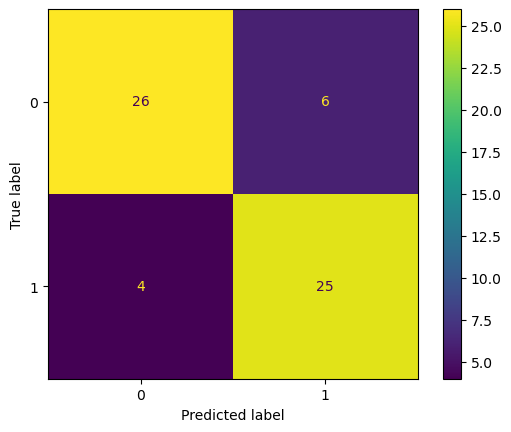

In [737]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

In [738]:
cm = confusion_matrix(y_test, y_pred1)
print(cm)

[[24  8]
 [ 5 24]]


In [739]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot

In [747]:
cm = confusion_matrix(y_test,y_pred1)

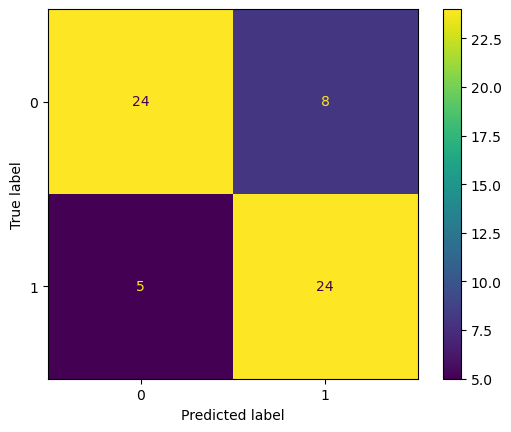

In [748]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

In [657]:
cm = confusion_matrix(y_test, y_pred2)
print(cm)

[[24  8]
 [ 4 25]]


In [658]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [749]:
cm = confusion_matrix(y_test,y_pred2)

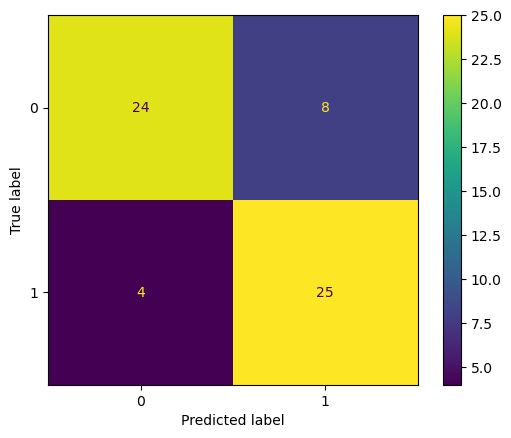

In [750]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()